# 第一讲：深度学习骨架拆解

这一讲先不急着堆模型。

我们先把后面会反复遇到的几件事讲清楚：

- 图像分类任务里，输入到底是什么，标签是什么
- 一次训练到底发生了什么
- `loss`、`梯度`、`学习率`、参数更新之间是什么关系
- PyTorch 里最常用的几个接口分别在做什么

这一讲讲完以后，你至少应该建立一个基本感觉：以后看到任何视觉模型，不管是 CNN、ViT，还是后面的生成模型，它训练时都离不开同一条主线：

`输入 -> 前向计算 -> loss -> 反向传播 -> 参数更新 -> 验证评估`


## 1. 课程位置与底层基建

<img src='images/lesson1_intro/course_map.png' width='800'>

## 2. 软硬件基础设施就位

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import math

In [26]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Active Device: {device}')

Active Device: mps


## 3. 视觉数据解剖：FashionMNIST

In [27]:
transform = transforms.ToTensor()
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
val_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
classes = train_set.classes

共计 10 个核心类别。接下来我们对这 10 个类别进行全方位图鉴巡礼，以便你对模型将要挑战的任务有微观体感。

> [!TIP]\n> **[数据集原论文] Fashion-MNIST**\n> *Xiao, Rasul, & Vollgraf (2017). Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms.*\n> <img src='images/lesson1_papers/fashion_mnist_table2.png' width='720'>\n> 论文中的 Table 2 直接给出了 10 个类别的标准样例；我们后面看到的训练集图片，正是沿着这套定义在做分类。\n> [论文链接](https://arxiv.org/abs/1708.07747)

### 3.1 类别巡礼: T-shirt/top

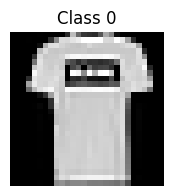

In [28]:
for img_idx in range(100):
    if train_set[img_idx][1] == 0:
        img_show, lbl = train_set[img_idx]
        plt.figure(figsize=(2,2))
        plt.imshow(img_show.squeeze().numpy(), cmap='gray')
        plt.title("Class " + str(lbl))
        plt.axis('off')
        plt.show()
        break

### 3.2 类别巡礼: Trouser

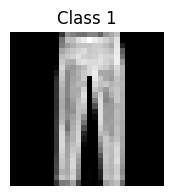

In [29]:
for img_idx in range(100):
    if train_set[img_idx][1] == 1:
        img_show, lbl = train_set[img_idx]
        plt.figure(figsize=(2,2))
        plt.imshow(img_show.squeeze().numpy(), cmap='gray')
        plt.title("Class " + str(lbl))
        plt.axis('off')
        plt.show()
        break

### 3.3 类别巡礼: Pullover

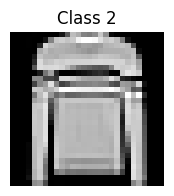

In [30]:
for img_idx in range(100):
    if train_set[img_idx][1] == 2:
        img_show, lbl = train_set[img_idx]
        plt.figure(figsize=(2,2))
        plt.imshow(img_show.squeeze().numpy(), cmap='gray')
        plt.title("Class " + str(lbl))
        plt.axis('off')
        plt.show()
        break

### 3.4 类别巡礼: Dress

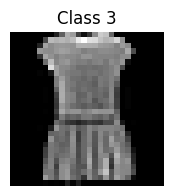

In [31]:
for img_idx in range(100):
    if train_set[img_idx][1] == 3:
        img_show, lbl = train_set[img_idx]
        plt.figure(figsize=(2,2))
        plt.imshow(img_show.squeeze().numpy(), cmap='gray')
        plt.title("Class " + str(lbl))
        plt.axis('off')
        plt.show()
        break

### 3.5 类别巡礼: Coat

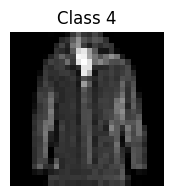

In [32]:
for img_idx in range(100):
    if train_set[img_idx][1] == 4:
        img_show, lbl = train_set[img_idx]
        plt.figure(figsize=(2,2))
        plt.imshow(img_show.squeeze().numpy(), cmap='gray')
        plt.title("Class " + str(lbl))
        plt.axis('off')
        plt.show()
        break

### 3.6 类别巡礼: Sandal

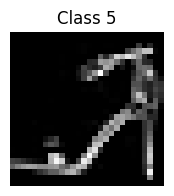

In [33]:
for img_idx in range(100):
    if train_set[img_idx][1] == 5:
        img_show, lbl = train_set[img_idx]
        plt.figure(figsize=(2,2))
        plt.imshow(img_show.squeeze().numpy(), cmap='gray')
        plt.title("Class " + str(lbl))
        plt.axis('off')
        plt.show()
        break

### 3.7 类别巡礼: Shirt

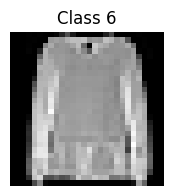

In [34]:
for img_idx in range(100):
    if train_set[img_idx][1] == 6:
        img_show, lbl = train_set[img_idx]
        plt.figure(figsize=(2,2))
        plt.imshow(img_show.squeeze().numpy(), cmap='gray')
        plt.title("Class " + str(lbl))
        plt.axis('off')
        plt.show()
        break

### 3.8 类别巡礼: Sneaker

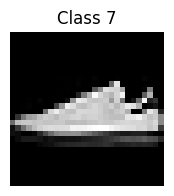

In [35]:
for img_idx in range(100):
    if train_set[img_idx][1] == 7:
        img_show, lbl = train_set[img_idx]
        plt.figure(figsize=(2,2))
        plt.imshow(img_show.squeeze().numpy(), cmap='gray')
        plt.title("Class " + str(lbl))
        plt.axis('off')
        plt.show()
        break

### 3.9 类别巡礼: Bag

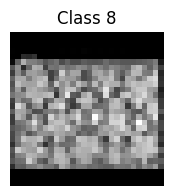

In [36]:
for img_idx in range(100):
    if train_set[img_idx][1] == 8:
        img_show, lbl = train_set[img_idx]
        plt.figure(figsize=(2,2))
        plt.imshow(img_show.squeeze().numpy(), cmap='gray')
        plt.title("Class " + str(lbl))
        plt.axis('off')
        plt.show()
        break

### 3.10 类别巡礼: Ankle boot

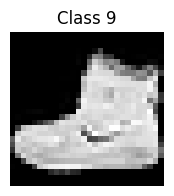

In [37]:
for img_idx in range(100):
    if train_set[img_idx][1] == 9:
        img_show, lbl = train_set[img_idx]
        plt.figure(figsize=(2,2))
        plt.imshow(img_show.squeeze().numpy(), cmap='gray')
        plt.title("Class " + str(lbl))
        plt.axis('off')
        plt.show()
        break

## 4. 张量深度微观分析

### 4.1 先把这张图的任务说清楚

这一节不是在训练模型，而是在回答一个更基础的问题：**一张图片进入神经网络之前，到底长什么样？**

这张图想说明的是：

- 人眼看到的是“衣服”
- 机器最先看到的不是语义，而是一个由像素数字组成的矩阵
- 每个位置都有一个数，表示这个像素有多亮或多暗

所以这一步是在帮我们建立输入视角：**神经网络吃进去的第一口，其实是数字，不是语义。**

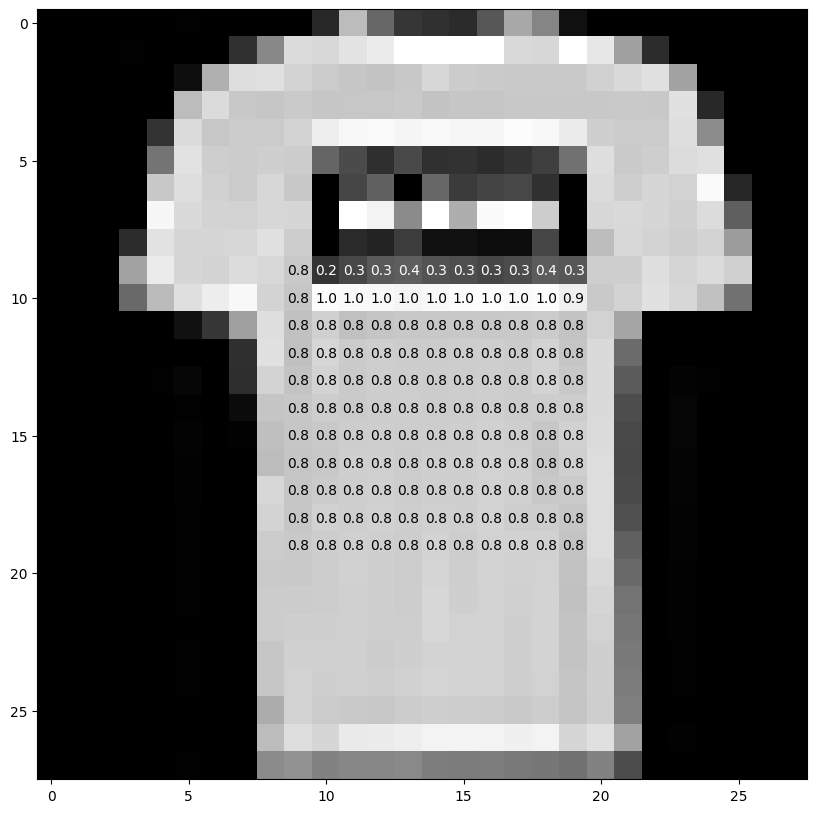

In [38]:
img_np = train_set[1][0].squeeze().numpy()
fig, ax = plt.subplots(1, 1, figsize=(10,10))
ax.imshow(img_np, cmap='gray')
for x in range(28):
    for y in range(28):
        if 8 < x < 20 and 8 < y < 20: 
            color = 'white' if img_np[x][y] < 0.5 else 'black'
            ax.annotate(str(round(img_np[x][y], 1)), xy=(y, x), ha='center', va='center', color=color, fontsize=10)
plt.show()

### 4.2 再往前走一步：它是怎样进入 MLP 的

看懂“图片是像素矩阵”以后，还差最后一层桥：**这些像素数字到底怎样被送进网络？**

对于这一讲使用的 MLP，关键动作就是 `Flatten`：

- 原始输入是一张 `1 × 28 × 28` 的图
- 进入 MLP 前，会先被拉平成一个 `784` 维向量
- 后面的第一层全连接，其实就在做：

$$
784 \rightarrow 256
$$

也就是说，后面的训练本质上是在学习：**如何把这 784 个像素数字，映射成 10 个类别中的正确答案。**

In [65]:
x0, y0 = train_set[1]
flat_x0 = x0.view(-1)

print("原始张量 shape:", x0.shape)
print("Flatten 之后 shape:", flat_x0.shape)
print("前 20 个像素值:", flat_x0[:20].numpy())
print("标签 id:", y0)
print("标签名称:", classes[y0])

原始张量 shape: torch.Size([1, 28, 28])
Flatten 之后 shape: torch.Size([784])
前 20 个像素值: [0.         0.         0.         0.         0.         0.00392157
 0.         0.         0.         0.         0.16078432 0.7372549
 0.40392157 0.21176471 0.1882353  0.16862746 0.34117648 0.65882355
 0.52156866 0.0627451 ]
标签 id: 0
标签名称: T-shirt/top


1. 一张图片对模型来说，本质上是像素矩阵
2. 进入 MLP 前，这个矩阵会被拉平成 `784` 个数字
3. 后面的训练，就是在学习如何根据这 `784` 个数字，输出正确类别

上面讲的是：**输入是什么。**

接下来第 5 节才开始讲另一个问题：**这些输入进入模型之后，参数是怎样靠 loss 和梯度一步一步更新的。**

## 5. 解剖大闭环：训练的本质

<img src='images/lesson1_intro/training_loop.png' width='800'>

### 5.0 这小节到底在说明什么

这一小节不是在单独讲一张数学图，而是在回答一个更核心的问题：**模型训练时，参数到底是怎么一步一步变好的？**

后面你会反复看到三个词：`Loss 曲面`、`梯度`、`梯度下降`。如果这三个关系没搞清楚，训练过程就会看起来像黑箱。

#### 先建立最直观的关系

- `Loss`：模型当前错得有多厉害
- `Loss 曲面`：把“参数取不同值时，loss 会变多少”画成一张地形图
- `梯度`：告诉你当前位置往哪个方向走，loss 会下降得最快
- `梯度下降`：按照梯度给出的方向，真的迈出一小步去更新参数

你可以把它想成爬山的反面：

- 山的高度 = loss
- 你脚下的位置 = 当前参数
- 梯度 = 当前地形最陡的方向
- 梯度下降 = 朝着让高度下降的方向走

所以这一节的目标就是：**先用只有 1 个参数的极简例子，把“地形长什么样、梯度怎么指路、参数怎么更新”看懂。**

### 5.1 手动画出 1D Loss 曲面与剃度下降

In [39]:
w_space = np.linspace(0, 10, 200)
loss_space = (w_space * 2.0 - 10.0)**2

#### 先看懂这张图的坐标轴

- 横轴 `w`：参数的取值，也就是你现在把模型参数调到哪里
- 纵轴 `loss`：当参数取这个值时，模型错得有多厉害

所以这张图本质上是在回答：**如果参数 `w` 取不同值，loss 会变成多少？**

图里的红色虚线画在 `w = 5`，因为这时

$$
(2 	imes 5 - 10)^2 = 0
$$

也就是这条曲线的最低点，对应全局最小值。

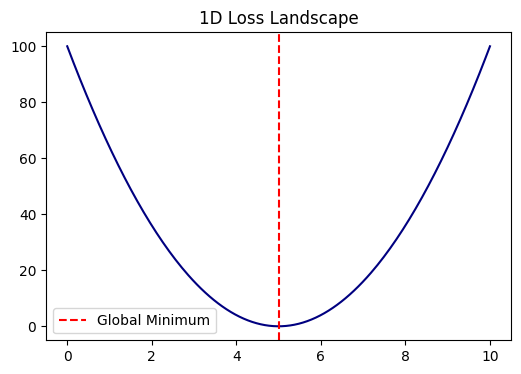

In [40]:
plt.figure(figsize=(6,4))
plt.plot(w_space, loss_space, color='navy')
plt.axvline(5, color='red', linestyle='--', label='Global Minimum')
plt.title("1D Loss Landscape")
plt.legend(); plt.show()

<img src='images/lesson1_intro/gradient_on_loss_curve.png' width='800'>

### 5.2 学习率探测实验室

#### 先看懂这个函数在干什么

这个函数不是在训练一个真正的大模型，而是在手工模拟 **“参数如何沿着梯度一步一步更新”**。它做的事情可以拆成 4 步：

1. 先设一个初始参数 `w`
2. 用当前 `w` 算出一次 `loss`
3. 用 `loss.backward()` 让 PyTorch 自动求出梯度 `w.grad`
4. 按照梯度下降公式更新参数：

$$
w \leftarrow w - \text{lr} \cdot \frac{\partial \text{loss}}{\partial w}
$$

其中：

- `lr` 是学习率，决定每一步走多大
- `w.grad` 就是当前这个位置的梯度
- `w_t` 和 `l_t` 是把每一步的参数位置和 loss 记录下来，方便后面画轨迹图

所以这个函数本质上是在回答：**如果学习率不同，参数会以什么方式沿着 loss 曲面移动？**

In [41]:
def autograd_descent(lr, steps=8, initial_w=-1.0):
    w = torch.tensor([initial_w], requires_grad=True)
    w_t, l_t = [], []
    for _ in range(steps):
        loss = (w * 2.0 - 10.0)**2
        w_t.append(w.item())
        l_t.append(loss.item())
        loss.backward()
        with torch.no_grad():
            w -= lr * w.grad
            w.grad.zero_()
    return w_t, l_t

### LR = 0.005 (蠕动)

#### 这张图在说明什么

- 灰色曲线：整个 `loss` 曲面，也就是参数 `w` 取不同值时，loss 怎么变化
- 紫色点：每一步更新后，参数落在曲线上的位置
- 紫色虚线：把这些点连起来，表示参数移动的轨迹

这张图想说明的是：**当学习率 `lr = 0.005` 太小时，方向虽然是对的，但每一步走得太短，所以收敛会非常慢。**

也就是说，模型不是不会学，而是学得像“挪小碎步”，8 步下来还离最低点很远。

#### 为什么 `lr` 太小会让 loss 降得慢

`lr` 不会改变 loss 的定义本身，但会影响 **loss 下降的速度**。因为参数更新公式是：

$$
w \leftarrow w - \text{lr} \cdot \frac{\partial \text{loss}}{\partial w}
$$

如果 `lr` 很小，那么即使梯度方向是对的，每一步参数也只会挪一点点。参数没怎么动，loss 自然也就只会降一点点。

所以 `lr` 太小时，不是模型完全不会学，而是它会学得非常慢，看起来像“几乎没动”。

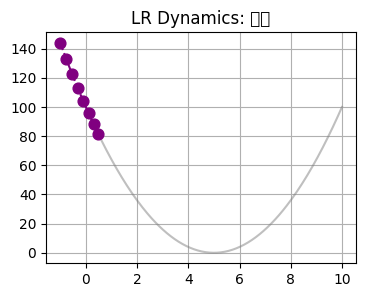

In [42]:
wt, lt = autograd_descent(0.005, steps=8)
plt.figure(figsize=(4,3))
plt.plot(w_space, loss_space, color='gray', alpha=0.5)
plt.scatter(np.clip(wt, -2, 12), np.clip(lt, 0, 150), color='purple', s=60, zorder=5)
plt.plot(np.clip(wt, -2, 12), np.clip(lt, 0, 150), color='purple', linestyle='--')
plt.title('LR Dynamics: ' + '蠕动')
plt.grid(); plt.show()

### LR = 0.05 (完美)

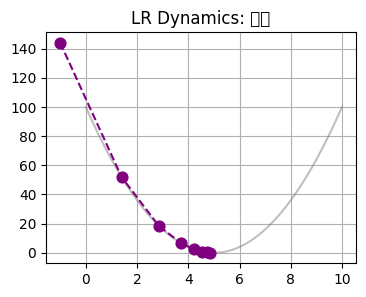

In [43]:
wt, lt = autograd_descent(0.05, steps=8)
plt.figure(figsize=(4,3))
plt.plot(w_space, loss_space, color='gray', alpha=0.5)
plt.scatter(np.clip(wt, -2, 12), np.clip(lt, 0, 150), color='purple', s=60, zorder=5)
plt.plot(np.clip(wt, -2, 12), np.clip(lt, 0, 150), color='purple', linestyle='--')
plt.title('LR Dynamics: ' + '完美')
plt.grid(); plt.show()

### LR = 0.18 (震荡)

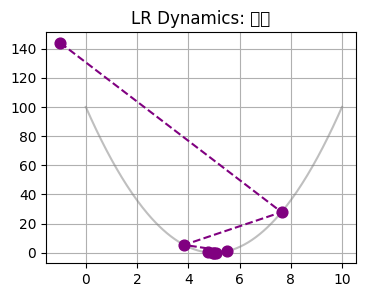

In [44]:
wt, lt = autograd_descent(0.18, steps=8)
plt.figure(figsize=(4,3))
plt.plot(w_space, loss_space, color='gray', alpha=0.5)
plt.scatter(np.clip(wt, -2, 12), np.clip(lt, 0, 150), color='purple', s=60, zorder=5)
plt.plot(np.clip(wt, -2, 12), np.clip(lt, 0, 150), color='purple', linestyle='--')
plt.title('LR Dynamics: ' + '震荡')
plt.grid(); plt.show()

### LR = 0.26 (发散)

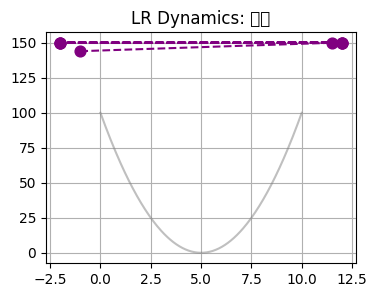

In [45]:
wt, lt = autograd_descent(0.26, steps=8)
plt.figure(figsize=(4,3))
plt.plot(w_space, loss_space, color='gray', alpha=0.5)
plt.scatter(np.clip(wt, -2, 12), np.clip(lt, 0, 150), color='purple', s=60, zorder=5)
plt.plot(np.clip(wt, -2, 12), np.clip(lt, 0, 150), color='purple', linestyle='--')
plt.title('LR Dynamics: ' + '发散')
plt.grid(); plt.show()

## 6. 非线性重器：激活层原典

> [!NOTE]\n> **[基础开山之作] ReLU 被大规模证明有效**\n> *Nair, V., & Hinton, G. E. (2010). Rectified Linear Units Improve Restricted Boltzmann Machines.*\n> 这是拯救深度网络免于梯度消失的终极函数。

> [!TIP]\n> **[激活函数家族图] PReLU vs. ReLU**\n> *He et al. (2015). Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification.*\n> <img src='images/lesson1_papers/prelu_fig1.png' width='560'>\n> 这张原论文图把 `ReLU` 与 `PReLU` 的形状差异画得很清楚：经典 ReLU 在负半轴直接截断，而 PReLU 允许负半轴保留一个可学习斜率。\n> [论文链接](https://arxiv.org/abs/1502.01852)

### 6.0 为什么激活函数这么关键

激活函数的作用，不只是“把线性层后面接一个非线性”。它至少解决三件事：

1. 没有激活函数，多层线性层叠加后本质上还是线性变换，模型表达力会塌成一层。
2. 激活函数决定信号如何通过，也决定梯度如何反向传播。
3. 激活函数的形状和偏导数，直接影响训练时会不会出现梯度消失、梯度中断、训练不稳定等问题。

| 激活函数 | 数学输出范围 | 偏导数范围 | 典型优点 | 典型风险 |
|---|---|---|---|---|
| Sigmoid | $(0,1)$ | $(0,0.25]$ | 输出像概率，解释直观 | 深层网络里容易梯度消失 |
| Tanh | $(-1,1)$ | $(0,1]$ | 零中心，通常比 Sigmoid 更好训 | 两端仍会饱和 |
| ReLU | $[0,+\infty)$ | $0$ 或 $1$ | 简单、快、深层训练稳定 | 负半轴可能“死亡” |
| LeakyReLU | $(-\infty,+\infty)$ | 负半轴是小常数，正半轴是 $1$ | 缓解 ReLU 死亡问题 | 负半轴斜率需要人工设定 |

### Sigmoid 分布与偏导测试

#### 定义与公式：Sigmoid

**数学公式**

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

**偏导数公式**

$$
\sigma'(x) = \sigma(x)(1-\sigma(x))
$$

Sigmoid 会把任意实数压到 `0` 到 `1` 之间。

#### 使用场景：Sigmoid

- 最常见于二分类输出层
- 适合把输出解释成概率
- 现在通常不再作为深层隐藏层的主力激活函数

#### 看图前先记住

- 偏导数衡量的是：输入变化一点点，输出会变化多少
- 对反向传播来说，它决定梯度信号能不能继续往前传
- Sigmoid 在两端会饱和，此时导数接近 `0`，所以它是梯度消失的高发地带

#### 解读 1：链式法则视角下，梯度为什么会越传越小

假设有一个很简单的深层链式结构：

$$
a_1 \rightarrow a_2 \rightarrow a_3 \rightarrow \cdots \rightarrow a_L \rightarrow \mathcal{L}
$$

根据链式法则，最前面第 1 层的梯度可以写成：

$$
\frac{\partial \mathcal{L}}{\partial a_1}
= \frac{\partial \mathcal{L}}{\partial a_L}
\cdot
\frac{\partial a_L}{\partial a_{L-1}}
\cdot
\frac{\partial a_{L-1}}{\partial a_{L-2}}
\cdots
\frac{\partial a_2}{\partial a_1}
$$

这里前面那一项是后面传回来的梯度信号，后面一连串乘上的项是每一层的局部导数。

#### 解读 2：一个数字例子

如果为了直观举例，假设每一层的局部导数都只有 `0.2`，那么：

$$
\frac{\partial \mathcal{L}}{\partial a_1}
\approx
\frac{\partial \mathcal{L}}{\partial a_L}
\cdot (0.2)^{L-1}
$$

如果最后一层传回来的梯度大小是 `1`，网络一共有 `6` 层，那么：

$$
\frac{\partial \mathcal{L}}{\partial a_1}
\approx 1 \cdot (0.2)^5 = 0.00032
$$

前面层几乎就听不到后面的反馈了。

#### 解读 3：回到 Sigmoid 本身

如果某一层有

$$
a^{(l)} = \sigma(z^{(l)})
$$

那么它的局部导数就是

$$
\frac{\partial a^{(l)}}{\partial z^{(l)}}
= \sigma(z^{(l)})(1-\sigma(z^{(l)}))
$$

而这个值最大也只有 `0.25`。

所以一句话总结：梯度不是一下子跳回最前面，而是每过一层都要乘上一个局部导数；如果每层都只剩一点点，传得越远，剩下越少。

/Users/mlyuan413/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mlyuan413/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20989 (\N{CJK UNIFIED IDEOGRAPH-51FD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mlyuan413/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mlyuan413/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20559 (\N{CJK UNIFIED IDEOGRAPH-504F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mlyuan413/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 

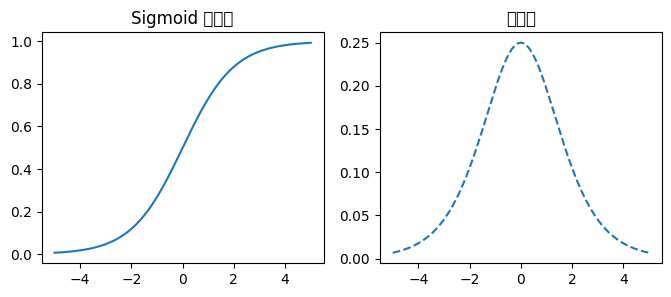

In [46]:
x_ax = torch.linspace(-5, 5, 200, requires_grad=True)
y_ax = torch.sigmoid(x_ax)
y_ax.backward(torch.ones_like(x_ax))
grad_ax = x_ax.grad.clone()
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].plot(x_ax.detach(), y_ax.detach()); ax[0].set_title(f"Sigmoid 原函数")
ax[1].plot(x_ax.detach(), grad_ax.detach(), linestyle='--'); ax[1].set_title(f"偏导数")
plt.show()

### Tanh 分布与偏导测试

#### 定义与公式：Tanh

**数学公式**

$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

**偏导数公式**

$$
\tanh'(x) = 1 - \tanh^2(x)
$$

Tanh 会把输出压到 `-1` 到 `1` 之间。

#### 使用场景：Tanh

- 早期 MLP / RNN 隐藏层里非常常见
- 现在在部分循环网络结构里仍然常见
- 在深层前馈网络里，很多场景已被 ReLU 家族替代

#### 看图前先记住

- 相比 Sigmoid，Tanh 是零中心的，所以优化起来通常更顺一点
- 在 `x` 接近 `0` 时，导数接近 `1`，梯度能比较完整地穿过去
- 但在两端大正大负区域，导数仍会接近 `0`，所以它依然会饱和

#### 解读：为什么说 Tanh 更适合隐藏层

先看导数大小：

- `Sigmoid` 的导数最大只有 `0.25`
- `Tanh` 的导数最大可以到 `1`

所以在中间区域，Tanh 传梯度更强，更利于训练。

#### 但它没有彻底解决问题

当 $x$ 很大或很小时：

$$
\tanh(x) \to 1 \quad \text{或} \quad -1
$$

这时

$$
\tanh'(x) = 1 - \tanh^2(x) \to 0
$$

也就是说，只要输入跑到两端，Tanh 一样会饱和，导数一样会变得很小。

#### 一句话总结

`Tanh` 是“比 Sigmoid 更好传梯度”，不是“不会梯度消失”。它是缓解，不是根治。

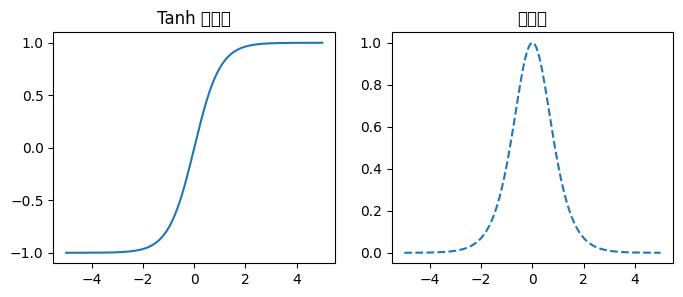

In [47]:
x_ax = torch.linspace(-5, 5, 200, requires_grad=True)
y_ax = torch.tanh(x_ax)
y_ax.backward(torch.ones_like(x_ax))
grad_ax = x_ax.grad.clone()
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].plot(x_ax.detach(), y_ax.detach()); ax[0].set_title(f"Tanh 原函数")
ax[1].plot(x_ax.detach(), grad_ax.detach(), linestyle='--'); ax[1].set_title(f"偏导数")
plt.show()

### ReLU 分布与偏导测试

#### 定义与公式：ReLU

**数学公式**

$$
\mathrm{ReLU}(x) = \max(0, x)
$$

**偏导数公式**

$$
\mathrm{ReLU}'(x) =
\begin{cases}
0, & x < 0 \\
1, & x > 0
\end{cases}
$$

在 $x=0$ 处严格说不可导，但工程实现里通常直接定义成固定值。

#### 使用场景：ReLU

- 现代 CNN、MLP 里最常见的隐藏层激活函数之一
- 如果你不知道先试什么，ReLU 往往是强基线
- 它简单、快，而且在正半轴很利于深层训练

#### 看图前先记住

- 在正半轴导数恒为 `1`，梯度可以很直接地往前传
- 在负半轴导数为 `0`，神经元如果长期落在负区间，可能再也学不回来
- 这就是著名的 **dying ReLU** 问题

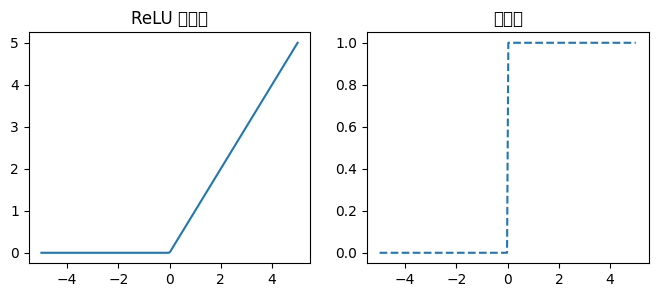

In [48]:
x_ax = torch.linspace(-5, 5, 200, requires_grad=True)
y_ax = torch.relu(x_ax)
y_ax.backward(torch.ones_like(x_ax))
grad_ax = x_ax.grad.clone()
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].plot(x_ax.detach(), y_ax.detach()); ax[0].set_title(f"ReLU 原函数")
ax[1].plot(x_ax.detach(), grad_ax.detach(), linestyle='--'); ax[1].set_title(f"偏导数")
plt.show()

### LeakyReLU 分布与偏导测试

#### 定义与公式：LeakyReLU

**数学公式**

$$
\mathrm{LeakyReLU}(x) =
\begin{cases}
x, & x > 0 \\
\alpha x, & x \le 0
\end{cases}
$$

其中 $\alpha$ 通常是一个很小的常数，比如 `0.01` 或 `0.1`。

**偏导数公式**

$$
\mathrm{LeakyReLU}'(x) =
\begin{cases}
1, & x > 0 \\
\alpha, & x \le 0
\end{cases}
$$

#### 使用场景：LeakyReLU

- 如果你发现 ReLU 把很多负数都直接砍成了 `0`，担心有些神经元以后一直不工作了，可以试试它
- 当你想保留 ReLU 的简单好用，但又不想让负半轴一点梯度都没有时，它是一个很自然的改进版
- 实战里如果 `ReLU` 训练效果一般，拿 `LeakyReLU` 直接替换做个对照实验，通常成本很低

#### 看图前先记住

- 负半轴导数不再是 `0`，而是一个小常数
- 即使神经元当前输出为负，它依然能收到一点梯度
- 所以 LeakyReLU 的核心价值，就是在保留 ReLU 简洁性的同时，缓解神经元死亡问题

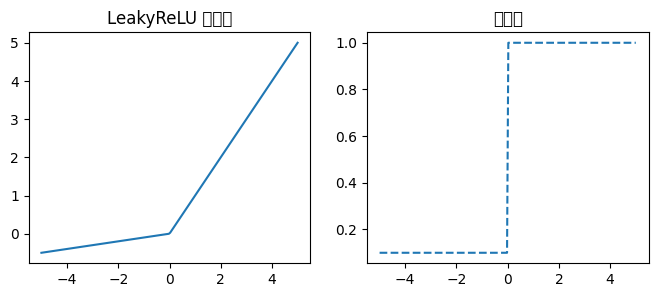

In [49]:
x_ax = torch.linspace(-5, 5, 200, requires_grad=True)
y_ax = torch.nn.functional.leaky_relu(x_ax, 0.1)
y_ax.backward(torch.ones_like(x_ax))
grad_ax = x_ax.grad.clone()
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].plot(x_ax.detach(), y_ax.detach()); ax[0].set_title(f"LeakyReLU 原函数")
ax[1].plot(x_ax.detach(), grad_ax.detach(), linestyle='--'); ax[1].set_title(f"偏导数")
plt.show()

## 7. 现代深度网络的维稳双煞：BatchNorm 与 Dropout

> [!NOTE]\n> **[基石论文] 批归一化 (BatchNorm)**\n> *Ioffe & Szegedy (2015). Batch Normalization: Accelerating Deep Network Training...*\n> <img src='images/lesson1_papers/batchnorm_page1.png' width='800'>\n> 消除内部协变量偏移，让模型各层输入分布稳定，极大地允许了我们使用更大的学习率！

### 7.1 BatchNorm 的定义

BatchNorm 会在训练时，拿一个 mini-batch 里的同一维特征，先做标准化，再交给网络继续往后算。它不是简单“把数变小”，而是让每层看到的数值尺度别老是乱飘。

### 7.2 BatchNorm 的公式

对某一维激活 $x$，在一个 batch 内先求均值和方差：

$$
\mu_B = \frac{1}{m}\sum_{i=1}^{m} x_i, \qquad
\sigma_B^2 = \frac{1}{m}\sum_{i=1}^{m}(x_i-\mu_B)^2
$$

然后做标准化：

$$
\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}
$$

最后再做一次可学习的缩放和平移：

$$
y_i = \gamma \hat{x}_i + \beta
$$

这里 $\gamma$ 和 $\beta$ 都是可学习参数。

### 7.3 BatchNorm 的直觉

前面层参数一变，后面层收到的输入分布也会跟着变。后面层就像在一个不断晃动的地板上学习，很难稳定收敛。BatchNorm 的作用，就是尽量把这个“老在变的输入分布”拉得更稳一点。

### 7.4 为什么它让更大学习率变得可用

如果没有 BatchNorm，某层输入数值一旦突然变大：

- 激活值可能爆掉
- 梯度可能振荡甚至发散
- 大学习率会让参数更新得过猛，训练很容易不稳定

有了 BatchNorm 之后，层输入会被重新拉回相对稳定的均值和方差附近，于是每层看到的数值尺度更可控，激活函数也不那么容易一下子冲进饱和区。你可以把它理解成：**BatchNorm 像是在每层前面加了一个自动稳压器。**

### 7.5 训练阶段和测试阶段的区别

- 训练时：用当前 batch 的均值和方差
- 测试时：改用训练过程中累计下来的 running mean / running var

这也是为什么 BatchNorm 在代码里通常会区分 `model.train()` 和 `model.eval()`。

### 7.6 BatchNorm 应该放在哪

**提问** 
BN 放在网络的哪个位置？
论文里建议放在「线性变换之后，激活函数之前」，比如 Conv -> BN -> ReLU，而不是 ReLU -> BN。为什么？

**最直观的对比**

✅ 正确：Conv → BN → ReLU
Conv 输出：分布乱飘
BN：拉回均值 0 方差 1
ReLU：在干净稳定的分布上做非线性
❌ 错误：Conv → ReLU → BN
Conv 输出：分布乱飘
ReLU：截断、压扁、变非负
BN：在畸形分布上归一化，白忙活

### 7.7 Dropout 的核心直觉

> [!WARNING]\n> **[防过拟合圣经] Dropout**\n> *Srivastava et al. (2014). Dropout: A Simple Way to Prevent Neural Networks from Overfitting.*\n> <img src='images/lesson1_papers/dropout_fig1.png' width='760'>\n> 原论文 Figure 1 展示了标准网络与 thinned network 的对应关系。训练期每一步都在采样不同的子网络，测试期再把这些子网络的能力折叠回一个完整模型。\n> [论文链接](https://jmlr.org/papers/v15/srivastava14a.html)

In [50]:
from torch.utils.data import DataLoader
batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

## 8. 一砖一瓦搭建带 BN 和 Dropout 的现代 MLP

<img src='images/lesson1_intro/one_training_step_detail.png' width='800'>

### 8.1 全连接隐层：784 -> 256

### 8.2 全连接隐层：256 -> 128

### 8.3 全连接隐层：128 -> 64

### 8.4 全连接隐层：64 -> 10

In [51]:
class ModernMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.net(self.flatten(x))

model = ModernMLP().to(device)
print(model)

ModernMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=64, out_features=10, bias=True)
  )
)


## 9. 训练逻辑装配与 Adam 登场

> [!IMPORTANT]\n> **[优化终极形态] Adam 优化器**\n> *Kingma & Ba (2014). Adam: A Method for Stochastic Optimization.*\n> <img src='images/lesson1_papers/adam_page1.png' width='800'>\n> 结合 RMSProp 和 Momentum 的自适应利器。

### 9.1 Adam 的定义

- `SGD`：所有参数共享同一个固定学习率
- `Adam`：每个参数都有自己的自适应更新尺度

最关键的直觉是：梯度大的参数，步子会自动变小；梯度小的参数，步子会自动变大。

### 9.2 Adam 和 SGD 的核心区别

$$
\theta_t = \theta_{t-1} - \alpha \cdot g_t
$$

$$
\theta_t = \theta_{t-1} - \alpha \cdot \frac{\hat m_t}{\sqrt{\hat v_t} + \epsilon}
$$

所以 Adam 的本质不是“更神秘的 SGD”，而是 **给每个参数配了一个会自动调节的学习率**。

### 9.3 Adam 自适应的本质

Adam 会对每个参数单独计算一个自适应学习率：

- 梯度大的参数，学习率自动变小
- 梯度小的参数，学习率自动变大

它依赖两类统计量：

- **一阶矩（均值）**：记录梯度的平均方向，作用很像动量
- **二阶矩（方差 / 幅度）**：记录梯度平方的平均大小，用来衡量梯度波动有多大

因此 Adam 不是只看“当前这一瞬间的梯度”，而是同时考虑：

- 最近一段时间，大方向往哪里走
- 这个参数的梯度到底稳定不稳定、剧烈不剧烈

这就是它能做到自适应学习率的原因。

### 9.4 Adam 的符号定义

- $g_t = \nabla_\theta J(\theta_{t-1})$：第 $t$ 步梯度
- $\alpha$：基础学习率
- $\beta_1$：一阶矩衰减系数
- $\beta_2$：二阶矩衰减系数
- $\epsilon$：防止除零的小常数

### 9.5 Adam 的四步更新公式

**步骤 1：一阶矩**

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t
$$

**步骤 2：二阶矩**

$$
v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2
$$

**步骤 3：偏差校正**

$$
\hat m_t = \frac{m_t}{1-\beta_1^t}, \qquad \hat v_t = \frac{v_t}{1-\beta_2^t}
$$

**步骤 4：最终更新**

$$
\theta_t = \theta_{t-1} - \alpha \cdot \frac{\hat m_t}{\sqrt{\hat v_t} + \epsilon}
$$

### 9.6 一个极简数值例子：先设定场景

- 只有 1 个参数 $\theta$
- 初始值：$\theta_0 = 10$
- 基础学习率：$\alpha = 1$
- 超参数：$\beta_1 = 0.9, \beta_2 = 0.999, \epsilon \approx 0$
- 初始动量：$m_0 = 0, v_0 = 0$

### 9.7 第 1 步：梯度较小时

假设第 1 步梯度是 $g_1 = 2$。

$$
m_1 = 0.9 \times 0 + 0.1 \times 2 = 0.2
$$

$$
v_1 = 0.999 \times 0 + 0.001 \times (2^2) = 0.004
$$

$$
\hat m_1 = 2, \qquad \hat v_1 = 4
$$

$$
\theta_1 = 10 - 1 \times \frac{2}{\sqrt{4}} = 9
$$

### 9.8 第 2 步：梯度突然变大时

假设第 2 步梯度变成 $g_2 = 10$。

$$
m_2 = 0.9 \times 0.2 + 0.1 \times 10 = 1.18
$$

$$
v_2 = 0.999 \times 0.004 + 0.001 \times (10^2) = 0.103996
$$

$$
\hat m_2 \approx 6.21, \qquad \hat v_2 \approx 52
$$

有效步长大约只有 `0.86`，所以参数更新到：

$$
\theta_2 = 9 - 1 \times 0.86 = 8.14
$$

### 9.9 这个例子说明了什么

- 第 1 步梯度小，$g=2$，有效步长约为 `1.0`
- 第 2 步梯度大，$g=10$，有效步长反而只有约 `0.86`

所以一句话总结 Adam：**它不是单纯走得更快，而是走得更会看路。**

In [52]:
loss_fn = nn.CrossEntropyLoss()

In [53]:
optimizer = optim.Adam(model.parameters(), lr=0.002)

In [54]:
def train_one_epoch(model, dataloader, optimizer, loss_fn):
    model.train()
    total_l, total_c, num = 0.0, 0, 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_l += loss.item() * len(x)
        total_c += (logits.argmax(1) == y).sum().item()
        num += len(x)
    return total_l / num, total_c / num

In [55]:
@torch.no_grad()
def evaluate(model, dataloader, loss_fn):
    model.eval()
    total_l, total_c, num = 0.0, 0, 0
    y_p, y_t = [], []
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        
        pred = logits.argmax(1)
        total_l += loss.item() * len(x)
        total_c += (pred == y).sum().item()
        num += len(x)
        y_p.extend(pred.cpu().numpy()); y_t.extend(y.cpu().numpy())
    return total_l / num, total_c / num, y_p, y_t

## 10. 全力开火！启动 5 轮大轮回跑批

In [56]:
t_ls, v_ls, t_as, v_as = [], [], [], []
for ep in range(5):
    tl, ta = train_one_epoch(model, train_loader, optimizer, loss_fn)
    vl, va, p_res, y_res = evaluate(model, val_loader, loss_fn)
    t_ls.append(tl); v_ls.append(vl)
    t_as.append(ta); v_as.append(va)
    print(f"Epoch {ep+1:02d} | TL: {tl:.4f} TA: {ta*100:.1f}% | VL: {vl:.4f} VA: {va*100:.1f}%")

Epoch 01 | TL: 0.5197 TA: 82.2% | VL: 0.4124 VA: 85.1%
Epoch 02 | TL: 0.3762 TA: 86.2% | VL: 0.3745 VA: 86.1%
Epoch 03 | TL: 0.3443 TA: 87.4% | VL: 0.3483 VA: 87.1%
Epoch 04 | TL: 0.3206 TA: 88.1% | VL: 0.3404 VA: 87.3%
Epoch 05 | TL: 0.3029 TA: 88.7% | VL: 0.3653 VA: 85.7%


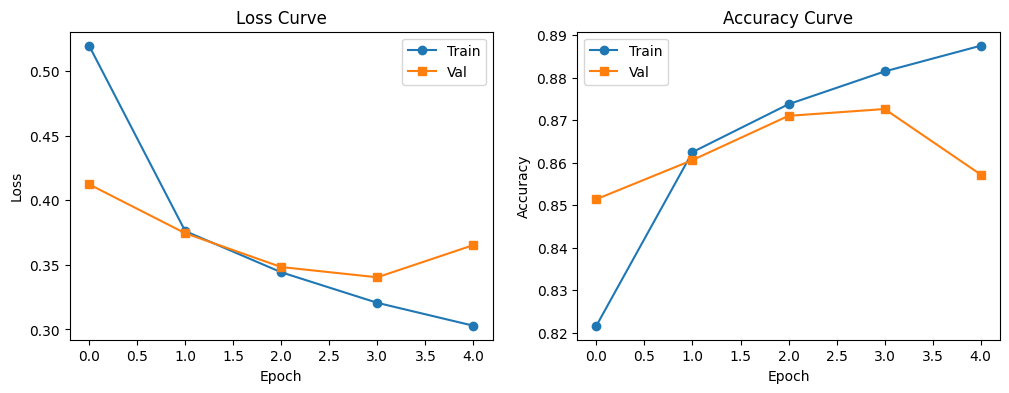

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(t_ls, marker='o', label='Train')
ax[0].plot(v_ls, marker='s', label='Val')
ax[0].set_title('Loss Curve')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].plot(t_as, marker='o', label='Train')
ax[1].plot(v_as, marker='s', label='Val')
ax[1].set_title('Accuracy Curve')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.show()

### 10.1 终极质检：混淆矩阵

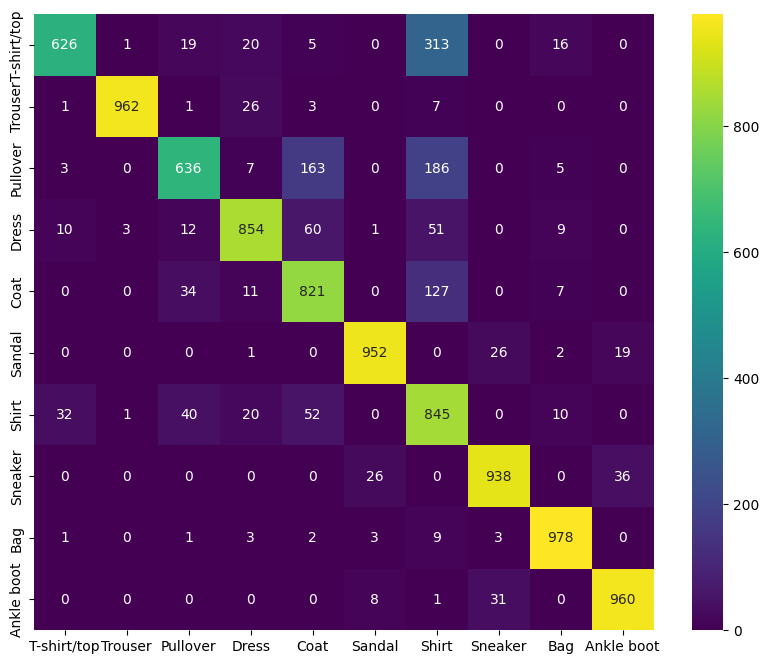

In [58]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_res, p_res)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=train_set.classes, yticklabels=train_set.classes)
plt.show()

## 11. 论文补图与轻量对比试验

### 11.1 先把概念说清楚

| 概念 | 一句话定义 | 它解决什么问题 |
|---|---|---|
| 初始化 (Initialization) | 在训练开始前，给网络参数一个合适的初始值分布 | 避免一开始就梯度爆炸或梯度消失 |
| 梯度传播 (Gradient Flow) | 损失函数对各层参数的误差信号如何从后往前传 | 决定深层网络能不能真正学到东西 |
| 优化器 (Optimizer) | 按照梯度来更新参数的规则 | 决定收敛速度、稳定性、对学习率的敏感度 |
| 正则化 (Regularization) | 约束模型不过度记忆训练集的机制 | 缓解过拟合，提升泛化 |
| Dropout | 训练时随机屏蔽一部分神经元 | 减少共适应，让模型别太依赖某几个单元 |

这几件事的关系可以概括成一句话: **初始化决定你能不能顺利起跑，优化器决定你怎么跑，正则化决定你会不会跑偏。**

### 11.2 先看两张论文图

先看原论文怎么解释初始化和梯度传播，再看我们自己的轻量实验。

> [!TIP]\n> **[初始化与梯度传播] Glorot & Bengio (2010)**\n> *Understanding the difficulty of training deep feedforward neural networks.*\n> <img src='images/lesson1_papers/glorot_fig7_gradients.png' width='520'>\n> 这张原论文 Figure 7 直接展示了: 标准初始化下，反向传播回来的梯度分布会快速塌陷；而归一化初始化能让梯度尺度更稳定。\n> [论文链接](https://proceedings.mlr.press/v9/glorot10a.html)

> [!TIP]\n> **[He 初始化的收敛优势] He et al. (2015)**\n> *Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification.*\n> <img src='images/lesson1_papers/he2015_fig2_init.png' width='620'>\n> 原论文 Figure 2 用训练误差曲线说明: 更合理的初始化不只是数学上更优雅，它会直接改变深层网络一开始能不能顺利降 loss。\n> [论文链接](https://arxiv.org/abs/1502.01852)

### 11.3 实验设置

下面我们用一个更轻量的 FashionMNIST 子集做两个小型 ablation，把论文里的论点和我们自己的 MLP 训练曲线接起来。

In [59]:
torch.manual_seed(42)
np.random.seed(42)

subset_gen = torch.Generator().manual_seed(42)
train_idx = torch.randperm(len(train_set), generator=subset_gen)[:12000].tolist()
val_idx = torch.randperm(len(val_set), generator=subset_gen)[:2000].tolist()

small_train = torch.utils.data.Subset(train_set, train_idx)
small_val = torch.utils.data.Subset(val_set, val_idx)
small_train_loader = DataLoader(small_train, batch_size=256, shuffle=True)
small_val_loader = DataLoader(small_val, batch_size=256, shuffle=False)

print(f"Ablation subset sizes -> train: {len(small_train)}, val: {len(small_val)}")

Ablation subset sizes -> train: 12000, val: 2000


In [60]:
class AblationMLP(nn.Module):
    def __init__(self, dropout_p=0.2):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(self.flatten(x))

def make_optimizer(name, params, lr):
    if name == 'Adam':
        return optim.Adam(params, lr=lr)
    if name == 'SGD':
        return optim.SGD(params, lr=lr, momentum=0.9)
    raise ValueError(name)

def run_ablation(optimizer_name='Adam', lr=0.002, dropout_p=0.2, epochs=3, seed=123):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = AblationMLP(dropout_p=dropout_p).to(device)
    optimizer = make_optimizer(optimizer_name, model.parameters(), lr)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for ep in range(epochs):
        tl, ta = train_one_epoch(model, small_train_loader, optimizer, loss_fn)
        vl, va, _, _ = evaluate(model, small_val_loader, loss_fn)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)
        print(f"{optimizer_name:>4} | dropout={dropout_p:.1f} | epoch {ep+1}: TL={tl:.4f} VL={vl:.4f} TA={ta*100:.1f}% VA={va*100:.1f}%")
    return history

### 11.4 优化器对比: `SGD` vs `Adam`

**定义**

- `SGD`：最基础的随机梯度下降。每一步基本就是沿着当前 batch 的梯度方向往下走。
- `Adam`：在 SGD 基础上叠加了一阶动量和二阶自适应学习率，对不同参数使用不同步长。

**优缺点对比**

| 方法 | 优势 | 劣势 | 典型使用感受 |
|---|---|---|---|
| SGD | 简单、稳定、最终泛化常常不错 | 对学习率敏感，前期收敛可能慢 | 需要更认真调参 |
| Adam | 前期下降快，对学习率没那么娇气 | 有时后期泛化不如调好的 SGD | 很适合先快速把模型训起来 |

**这组实验怎么读**

- 看 `Validation Loss`：谁下降更快，说明谁更容易把训练推进起来。
- 看 `Validation Accuracy`：谁在验证集上更高，说明谁当前泛化更好。
- 注意这里是一个小型子集实验，结论更适合用于“理解趋势”，而不是替代正式 benchmark。

In [61]:
adam_hist = run_ablation('Adam', lr=0.002, dropout_p=0.2, epochs=3, seed=123)
sgd_hist = run_ablation('SGD', lr=0.05, dropout_p=0.2, epochs=3, seed=123)

Adam | dropout=0.2 | epoch 1: TL=0.9191 VL=0.5154 TA=74.4% VA=82.2%
Adam | dropout=0.2 | epoch 2: TL=0.4968 VL=0.4571 TA=83.0% VA=83.3%
Adam | dropout=0.2 | epoch 3: TL=0.4259 VL=0.4894 TA=84.9% VA=81.4%
 SGD | dropout=0.2 | epoch 1: TL=0.8675 VL=0.4732 TA=71.7% VA=82.0%
 SGD | dropout=0.2 | epoch 2: TL=0.4862 VL=0.4777 TA=82.0% VA=82.2%
 SGD | dropout=0.2 | epoch 3: TL=0.4302 VL=0.4210 TA=83.9% VA=84.5%


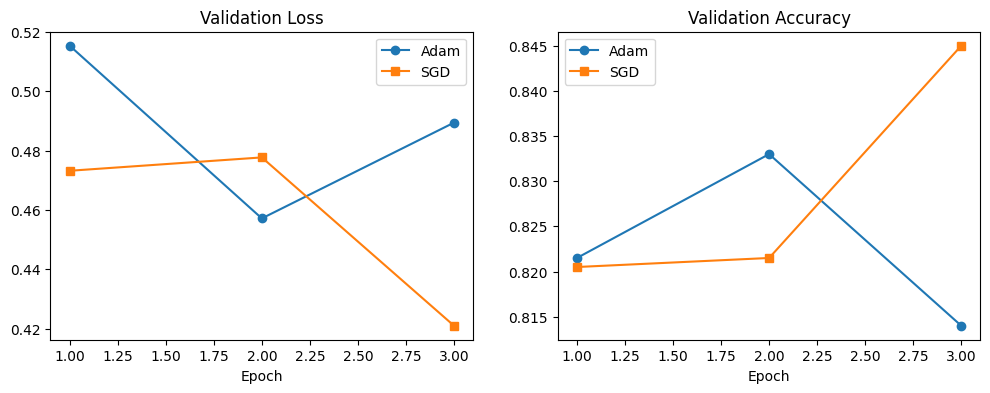

Adam final val acc: 81.4 %
SGD  final val acc: 84.5 %


In [62]:
epochs = np.arange(1, 4)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(epochs, adam_hist['val_loss'], marker='o', label='Adam')
ax[0].plot(epochs, sgd_hist['val_loss'], marker='s', label='SGD')
ax[0].set_title('Validation Loss')
ax[0].set_xlabel('Epoch')
ax[0].legend()
ax[1].plot(epochs, adam_hist['val_acc'], marker='o', label='Adam')
ax[1].plot(epochs, sgd_hist['val_acc'], marker='s', label='SGD')
ax[1].set_title('Validation Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].legend()
plt.show()

print('Adam final val acc:', round(adam_hist['val_acc'][-1] * 100, 2), '%')
print('SGD  final val acc:', round(sgd_hist['val_acc'][-1] * 100, 2), '%')

**结果解读**

- 如果 `Adam` 更快下降，说明它的自适应步长机制在早期优化上确实有帮助。
- 如果 `SGD` 最终验证精度反而略高，也不奇怪，这正是很多实际训练里会看到的现象：`Adam` 起步快，`SGD` 可能后劲更足。
- 所以真实工程里常见策略不是“谁永远更强”，而是根据阶段选工具：前期要快，常先试 `Adam`；后期追更稳的泛化，有时会回到 `SGD`。

### 11.5 正则化对比: `No Dropout` vs `Dropout(0.2)`

**定义**

- `No Dropout`：所有神经元每次都参与前向传播与反向传播。
- `Dropout(0.2)`：训练时约 20% 的单元会被随机置零，迫使网络不要过度依赖某条固定通路。

**优缺点对比**

| 方案 | 优势 | 劣势 | 你应该重点看什么 |
|---|---|---|---|
| No Dropout | 学得更快，训练精度通常更高 | 更容易过拟合 | `train acc` 和 `val acc` 是否拉开 |
| Dropout | 泛化更稳，抗过拟合能力更强 | 训练会更慢一点，训练精度往往更低 | 验证集曲线是否更平稳 |

**如何判断有没有过拟合**

- 如果 `train acc` 持续上升，但 `val acc` 不升反降，通常就是过拟合信号。
- 如果加入 Dropout 后训练精度略降、但验证表现更稳，这通常是健康的代价，而不是坏事。

In [63]:
no_drop_hist = run_ablation('Adam', lr=0.002, dropout_p=0.0, epochs=3, seed=123)
drop_hist = adam_hist

Adam | dropout=0.0 | epoch 1: TL=0.8159 VL=0.5042 TA=77.4% VA=83.0%
Adam | dropout=0.0 | epoch 2: TL=0.4383 VL=0.4641 TA=84.7% VA=83.2%
Adam | dropout=0.0 | epoch 3: TL=0.3614 VL=0.4985 TA=87.0% VA=82.2%


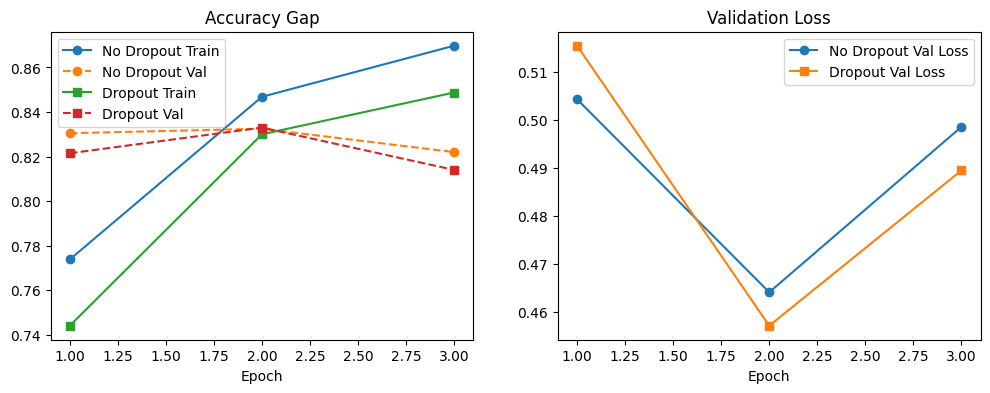

No Dropout final train/val acc: 86.98 % / 82.2 %
With Dropout final train/val acc: 84.88 % / 81.4 %


In [64]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(epochs, no_drop_hist['train_acc'], marker='o', label='No Dropout Train')
ax[0].plot(epochs, no_drop_hist['val_acc'], marker='o', linestyle='--', label='No Dropout Val')
ax[0].plot(epochs, drop_hist['train_acc'], marker='s', label='Dropout Train')
ax[0].plot(epochs, drop_hist['val_acc'], marker='s', linestyle='--', label='Dropout Val')
ax[0].set_title('Accuracy Gap')
ax[0].set_xlabel('Epoch')
ax[0].legend()
ax[1].plot(epochs, no_drop_hist['val_loss'], marker='o', label='No Dropout Val Loss')
ax[1].plot(epochs, drop_hist['val_loss'], marker='s', label='Dropout Val Loss')
ax[1].set_title('Validation Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend()
plt.show()

print('No Dropout final train/val acc:', round(no_drop_hist['train_acc'][-1] * 100, 2), '% /', round(no_drop_hist['val_acc'][-1] * 100, 2), '%')
print('With Dropout final train/val acc:', round(drop_hist['train_acc'][-1] * 100, 2), '% /', round(drop_hist['val_acc'][-1] * 100, 2), '%')

**结果解读**

- 在这次小实验里，`No Dropout` 的训练精度更高，这是符合预期的，因为模型约束更少。
- 更关键的是看 `train/val gap`：如果无 Dropout 版本训练集优势明显，但验证集没有同步受益，就说明模型开始“记住训练样本”了。
- Dropout 的价值不在于让训练指标更漂亮，而在于让模型面对没见过的数据时不那么脆弱。
- 一个典型的正面例子是：如果我们把训练轮数继续拉长，或者把网络再加宽一些，`No Dropout` 往往会继续把训练精度抬得很高，但验证集指标开始停滞甚至回落；这时带 `Dropout` 的版本虽然训练精度没那么“好看”，却更可能把验证集曲线维持得更平稳。
- 换句话说，`Dropout` 的优势通常不是短跑时立刻领先，而是在模型容量变大、训练时间变长、过拟合风险上升时，能更明显地体现出它的泛化保护作用。

这些图和小实验合起来表达的是同一件事: 深度学习训练效果并不只取决于网络层数, 还高度依赖 **梯度能否稳定传播、初始化是否合理、优化器是否足够聪明、正则化是否抑制住过拟合**。